In [1]:
import os
import shutil

# 0. Reset working directory to a safe place first
os.chdir('/content')

# 1. Clean previous clone if it exists
if os.path.exists('/content/SelfBlendedImages'):
    print("Old folder found — removing it for a clean start...")
    shutil.rmtree('/content/SelfBlendedImages')

# 2. Clone the repo
!git clone https://github.com/mapooon/SelfBlendedImages.git /content/SelfBlendedImages

# 3. Change into it using absolute path (safer than relative)
os.chdir('/content/SelfBlendedImages')

# 4. Install required libraries
!pip install timm segmentation-models-pytorch efficientnet_pytorch gdown -q

# 5. Create weights folder
os.makedirs('/content/SelfBlendedImages/weights', exist_ok=True)

print("\n Cube 1 Done! Repo cloned and dependencies installed.")
print(f" Current directory: {os.getcwd()}")
print(f" Contents: {os.listdir('.')}")

Cloning into '/content/SelfBlendedImages'...
remote: Enumerating objects: 85, done.
remote: Counting objects: 100% (50/50), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 85 (delta 34), reused 31 (delta 30), pack-reused 35 (from 1)
Receiving objects: 100% (85/85), 1.54 MiB | 4.82 MiB/s, done.
Resolving deltas: 100% (36/36), done.
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.2 MB/s eta 0:00:00

 Cube 1 Done! Repo cloned and dependencies installed.
 Current directory: /content/SelfBlendedImages
 Contents: ['weights', 'exec.sh', 'data', 'src', '.git', '.gitignore', 'build.sh', 'README.md', 'dockerfiles', 'LICENSE', 'overview.png']


In [2]:
import os
os.chdir('/content/SelfBlendedImages/weights')

# c23 weight file ID from the official README (different from FFraw!)
!gdown "https://drive.google.com/uc?id=1X0-NYT8KPursLZZdxduRQju6E52hauV0" -O FFc23.tar

# Verify
if os.path.exists('FFc23.tar'):
    size = os.path.getsize('FFc23.tar') / (1024 * 1024)
    print(f"\n File size: {size:.1f} MB")
    if size > 50:
        print(" Cube 2 Done! FFc23.tar downloaded successfully.")
    else:
        print(" File too small — may be corrupted or download was blocked.")
else:
    print(" File not found — download failed.")

Downloading...
From (original): https://drive.google.com/uc?id=1X0-NYT8KPursLZZdxduRQju6E52hauV0
From (redirected): https://drive.google.com/uc?id=1X0-NYT8KPursLZZdxduRQju6E52hauV0&confirm=t&uuid=9c503842-b8e9-4145-90ee-e0fa02855e31
To: /content/SelfBlendedImages/weights/FFc23.tar
100% 141M/141M [00:03<00:00, 42.9MB/s]

 File size: 134.7 MB
 Cube 2 Done! FFc23.tar downloaded successfully.


In [3]:
import sys
import torch
import os

# 1. Add src to path so Python can find model.py
sys.path.append('/content/SelfBlendedImages/src')

# 2. Import the Detector class
from model import Detector

# 3. Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Using device: {device}")

# 4. Load the c23 weights
weights_path = '/content/SelfBlendedImages/weights/FFc23.tar'

if not os.path.exists(weights_path):
    raise FileNotFoundError(f"Weights file missing: {weights_path}")

checkpoint = torch.load(weights_path, map_location=device)

# 5. Peek at what keys are inside
print(f"\n Keys in checkpoint: {list(checkpoint.keys()) if isinstance(checkpoint, dict) else type(checkpoint)}")

# 6. Load weights into model
model = Detector().to(device)
model.load_state_dict(checkpoint['model'])
model.eval()

print(f"\n Cube 3 Done! Model loaded and ready on {device}.")

 Using device: cuda

 Keys in checkpoint: ['model', 'optimizer', 'epoch']
Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/adv-efficientnet-b4-44fb3a87.pth" to /root/.cache/torch/hub/checkpoints/adv-efficientnet-b4-44fb3a87.pth


100%|██████████| 74.4M/74.4M [00:01<00:00, 43.3MB/s]


Loaded pretrained weights for efficientnet-b4

 Cube 3 Done! Model loaded and ready on cuda.


In [4]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, os

local_zip = '/content/Celeb-DF-v2.zip'

if not os.path.exists(local_zip):
    print(" Copying from Google Drive...")
    shutil.copy('/content/drive/MyDrive/Celeb-DF-v2.zip', local_zip)
else:
    print(" Zip already exists locally, skipping.")

size = os.path.getsize(local_zip) / (1024 ** 3)
print(f"\n File size: {size:.1f} GB")
if size > 1:
    print(" Cube 4 Done! Dataset ready.")
else:
    print(" File too small — something went wrong.")

Mounted at /content/drive
 Copying from Google Drive...

 File size: 9.3 GB
 Cube 4 Done! Dataset ready.


In [5]:
import zipfile
import os

local_zip = '/content/Celeb-DF-v2.zip'
extract_to = '/content/dataset_celeb'

if not os.path.exists(extract_to):
    print(" Extracting dataset... this will take a few minutes.")
    with zipfile.ZipFile(local_zip, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print(" Extraction complete!")
else:
    print(" Dataset already extracted, skipping.")

print("\n Dataset contents:")
for f in sorted(os.listdir(extract_to)):
    full = os.path.join(extract_to, f)
    if os.path.isdir(full):
        count = len(os.listdir(full))
        print(f"  - {f}/ ({count} items)")
    else:
        print(f"  - {f}")

test_list = os.path.join(extract_to, 'List_of_testing_videos.txt')
print("\nTest list exists:", os.path.exists(test_list))

 Extracting dataset... this will take a few minutes.
 Extraction complete!

 Dataset contents:
  - Celeb-real/ (590 items)
  - Celeb-synthesis/ (5639 items)
  - List_of_testing_videos.txt
  - YouTube-real/ (300 items)

Test list exists: True


In [6]:
# Install the RetinaFace package expected by SBI
!pip install -U retinaface_pytorch -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.5/64.5 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 98.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 124.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 96.2 MB/s eta 0:00:00


In [7]:
import os
import shutil

src = '/content/dataset_celeb/List_of_testing_videos.txt'
dst_dir = '/content/SelfBlendedImages/data/Celeb-DF-v2'
dst = os.path.join(dst_dir, 'List_of_testing_videos.txt')

os.makedirs(dst_dir, exist_ok=True)

if not os.path.exists(src):
    raise FileNotFoundError(f"Missing source file: {src}")

shutil.copy(src, dst)

print(" Copied test list file.")
print("Source exists:", os.path.exists(src))
print("Destination exists:", os.path.exists(dst))

with open(dst, 'r', encoding='utf-8') as f:
    lines = f.readlines()

print("Number of lines:", len(lines))
print("First 5 lines:")
for line in lines[:5]:
    print(line.strip())

 Copied test list file.
Source exists: True
Destination exists: True
Number of lines: 518
First 5 lines:
1 YouTube-real/00170.mp4
1 YouTube-real/00208.mp4
1 YouTube-real/00063.mp4
1 YouTube-real/00024.mp4
1 YouTube-real/00021.mp4


In [8]:
import os
import shutil

src_root = '/content/dataset_celeb'
dst_root = '/content/SelfBlendedImages/data/Celeb-DF-v2'
folders = ['Celeb-real', 'Celeb-synthesis', 'YouTube-real']

os.makedirs(dst_root, exist_ok=True)

for folder in folders:
    src_folder = os.path.join(src_root, folder)
    dst_folder = os.path.join(dst_root, folder)

    if not os.path.exists(src_folder) and not os.path.exists(dst_folder):
        raise FileNotFoundError(f"Folder not found in either place: {folder}")

    if os.path.exists(src_folder) and not os.path.exists(dst_folder):
        shutil.move(src_folder, dst_folder)
        print(f"Moved folder: {src_folder} -> {dst_folder}")
    else:
        print(f"Folder already ready: {dst_folder}")

for folder in folders:
    folder_path = os.path.join(dst_root, folder)
    videos_path = os.path.join(folder_path, 'videos')
    os.makedirs(videos_path, exist_ok=True)

    moved = 0
    for name in os.listdir(folder_path):
        src = os.path.join(folder_path, name)

        if name == 'videos':
            continue
        if os.path.isfile(src) and name.lower().endswith('.mp4'):
            dst = os.path.join(videos_path, name)
            shutil.move(src, dst)
            moved += 1

    print(f"{folder}: moved {moved} videos into {videos_path}")

print("\nFinal check:")
for folder in folders:
    videos_path = os.path.join(dst_root, folder, 'videos')
    count = len([f for f in os.listdir(videos_path) if f.lower().endswith('.mp4')])
    print(folder, "->", count, "videos")

test_list = os.path.join(dst_root, 'List_of_testing_videos.txt')
print("Test list exists:", os.path.exists(test_list))

Moved folder: /content/dataset_celeb/Celeb-real -> /content/SelfBlendedImages/data/Celeb-DF-v2/Celeb-real
Moved folder: /content/dataset_celeb/Celeb-synthesis -> /content/SelfBlendedImages/data/Celeb-DF-v2/Celeb-synthesis
Moved folder: /content/dataset_celeb/YouTube-real -> /content/SelfBlendedImages/data/Celeb-DF-v2/YouTube-real
Celeb-real: moved 590 videos into /content/SelfBlendedImages/data/Celeb-DF-v2/Celeb-real/videos
Celeb-synthesis: moved 5639 videos into /content/SelfBlendedImages/data/Celeb-DF-v2/Celeb-synthesis/videos
YouTube-real: moved 300 videos into /content/SelfBlendedImages/data/Celeb-DF-v2/YouTube-real/videos

Final check:
Celeb-real -> 590 videos
Celeb-synthesis -> 5639 videos
YouTube-real -> 300 videos
Test list exists: True


In [9]:
import os
os.chdir('/content/SelfBlendedImages')

print("Running official SBI inference on Celeb-DF with FF-c23 weights...")
!python3 src/inference/inference_dataset.py -w weights/FFc23.tar -d CDF -n 32

Running official SBI inference on Celeb-DF with FF-c23 weights...
Loaded pretrained weights for efficientnet-b4
Downloading: "https://github.com/ternaus/retinaface/releases/download/0.01/retinaface_resnet50_2020-07-20-f168fae3c.zip" to /root/.cache/torch/hub/checkpoints/retinaface_resnet50_2020-07-20-f168fae3c.zip
100% 96.9M/96.9M [00:02<00:00, 40.0MB/s]
 26% 136/518 [31:18<1:27:19, 13.71s/it]error in 501:data/Celeb-DF-v2/Celeb-real/videos/id10_0007.mp4
not enough values to unpack (expected 4, got 0)
 28% 144/518 [33:08<1:25:45, 13.76s/it]error in 139:data/Celeb-DF-v2/Celeb-real/videos/id10_0001.mp4
not enough values to unpack (expected 4, got 0)
error in 144:data/Celeb-DF-v2/Celeb-real/videos/id10_0001.mp4
not enough values to unpack (expected 4, got 0)
 30% 153/518 [35:14<1:24:15, 13.85s/it]error in 377:data/Celeb-DF-v2/Celeb-real/videos/id8_0009.mp4
not enough values to unpack (expected 4, got 0)
100% 518/518 [1:59:46<00:00, 13.87s/it]
CDF| AUC: 0.9292


In [10]:
import sys, os, torch, numpy as np, random
from tqdm import tqdm
from sklearn.metrics import roc_auc_score

# Exact same seed as inference_dataset.py
seed = 1
random.seed(seed)
torch.manual_seed(seed)
np.random.seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

sys.path.insert(0, '/content/SelfBlendedImages/src')
sys.path.insert(0, '/content/SelfBlendedImages/src/inference')
os.chdir('/content/SelfBlendedImages')

from model import Detector
from preprocess import extract_frames
from datasets import init_cdf
from retinaface.pre_trained_models import get_model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

_model = Detector().to(device)
_model.load_state_dict(torch.load('/content/SelfBlendedImages/weights/FFc23.tar', map_location=device)['model'])
_model.eval()

_face_detector = get_model('resnet50_2020-07-20', max_size=2048, device=device)
_face_detector.eval()

video_list, target_list = init_cdf()
output_list = []

for filename in tqdm(video_list, desc='Collecting predictions'):
    try:
        face_list, idx_list = extract_frames(filename, 32, _face_detector)
        with torch.no_grad():
            img = torch.tensor(face_list).to(device).float() / 255
            pred = _model(img).softmax(1)[:, 1]
        pred_list = []
        idx_img = -1
        for i in range(len(pred)):
            if idx_list[i] != idx_img:
                pred_list.append([])
                idx_img = idx_list[i]
            pred_list[-1].append(pred[i].item())
        pred_res = np.zeros(len(pred_list))
        for i in range(len(pred_res)):
            pred_res[i] = max(pred_list[i])
        output_list.append(pred_res.mean())
    except Exception as e:
        print(e)
        output_list.append(0.5)

all_probs  = np.array(output_list)
all_labels = np.array(target_list)

save_dir = '/content/drive/MyDrive/Deepfake_Project/Results_FFc23_CDF'
os.makedirs(save_dir, exist_ok=True)
np.save(f'{save_dir}/all_probs.npy', all_probs)
np.save(f'{save_dir}/all_labels.npy', all_labels)

print(f'AUC: {roc_auc_score(all_labels, all_probs):.4f}')
print(f' Saved to: {save_dir}')

Loaded pretrained weights for efficientnet-b4


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torch/hub.py:897: FutureWarning: Falling back to the old format < 1.6. This support will be deprecated in favor of default zipfile format introduced in 1.6. Please redo torch.save() to save it in the new zipfile format.
  return _legacy_zip_load(cached_file, model_dir, map_location, weights_only)
  img = torch.tensor(face_list).to(device).float() / 255

error in 501:data/Celeb-DF-v2/Celeb-real/videos/id10_0007.mp4
not enough values to unpack (expected 4, got 0)


error in 139:data/Celeb-DF-v2/Celeb-real/videos/id10_0001.mp4
not enough values to unpack (expected 4, got 0)
error in 144:data/Celeb-DF-v2/Celeb-real/videos/id10_0001.mp4
not enough values to unpack (expected 4, got 0)


error in 377:data/Celeb-DF-v2/Celeb-real/videos/id8_0009.mp4
not enough values to unpack (expected 4, got 0)


AUC: 0.9292
 Saved to: /content/drive/MyDrive/Deepfake_Project/Results_FFc23_CDF


Calculating Bootstrap CI...
AUC: 0.9292 (95% CI: [0.9076, 0.9491])


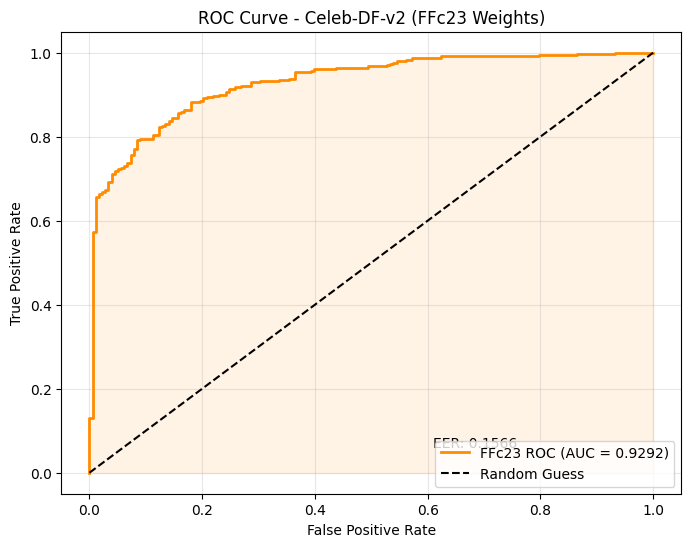

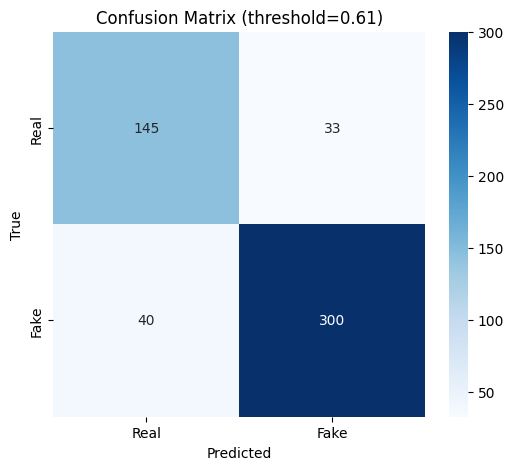

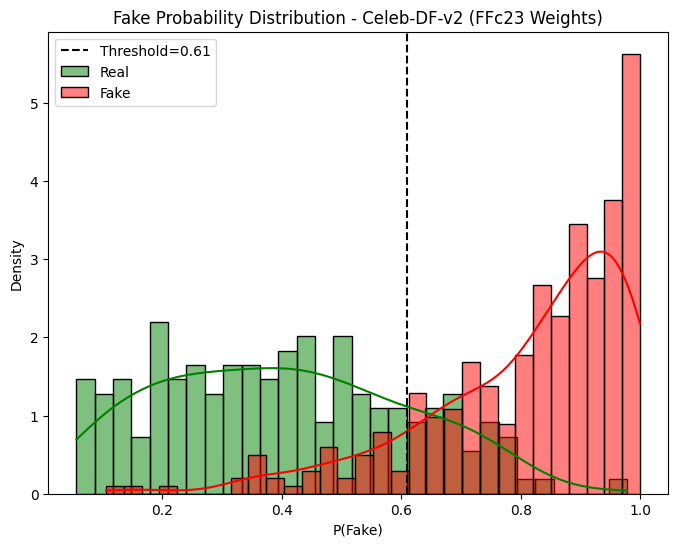


 Graphs saved to: /content/drive/MyDrive/Deepfake_Project/Results_FFc23_CDF/Graphs


In [11]:
import os, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import roc_curve, confusion_matrix, roc_auc_score, accuracy_score
from matplotlib.lines import Line2D

save_dir = '/content/drive/MyDrive/Deepfake_Project/Results_FFc23_CDF'
all_probs  = np.load(f'{save_dir}/all_probs.npy')
all_labels = np.load(f'{save_dir}/all_labels.npy')

graph_dir = os.path.join(save_dir, 'Graphs')
os.makedirs(graph_dir, exist_ok=True)
rng = np.random.RandomState(42)

# Best threshold
thresholds = np.arange(0.1, 0.91, 0.01)
best_thresh = thresholds[np.argmax([accuracy_score(all_labels, (all_probs >= t).astype(int)) for t in thresholds])]

# 1. Bootstrap CI
print('Calculating Bootstrap CI...')
bootstrapped_aucs = []
for _ in range(1000):
    idx = rng.randint(0, len(all_probs), len(all_probs))
    if len(np.unique(all_labels[idx])) < 2:
        continue
    bootstrapped_aucs.append(roc_auc_score(all_labels[idx], all_probs[idx]))
sorted_scores = np.sort(bootstrapped_aucs)
ci_lower = sorted_scores[int(0.025 * len(sorted_scores))]
ci_upper = sorted_scores[int(0.975 * len(sorted_scores))]
final_auc = roc_auc_score(all_labels, all_probs)
print(f'AUC: {final_auc:.4f} (95% CI: [{ci_lower:.4f}, {ci_upper:.4f}])')

# 2. ROC Curve + EER
fpr, tpr, _ = roc_curve(all_labels, all_probs)
fnr = 1 - tpr
eer = (fpr[np.argmin(np.abs(fpr - fnr))] + fnr[np.argmin(np.abs(fpr - fnr))]) / 2
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'FFc23 ROC (AUC = {final_auc:.4f})')
plt.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.text(0.6, 0.1, f'EER: {eer:.4f}', transform=plt.gca().transAxes, fontsize=10)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Celeb-DF-v2 (FFc23 Weights)')
plt.legend(loc='lower right'); plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(graph_dir, 'roc_curve.png'), dpi=300, bbox_inches='tight')
plt.show()

# 3. Confusion Matrix
cm = confusion_matrix(all_labels, (all_probs >= best_thresh).astype(int))
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title(f'Confusion Matrix (threshold={best_thresh:.2f})')
plt.savefig(os.path.join(graph_dir, 'confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

# 4. Probability Distribution
plt.figure(figsize=(8, 6))
sns.histplot([p for p, l in zip(all_probs, all_labels) if l == 0],
             color='green', label='Real', kde=True, stat='density', alpha=0.5, bins=30)
sns.histplot([p for p, l in zip(all_probs, all_labels) if l == 1],
             color='red', label='Fake', kde=True, stat='density', alpha=0.5, bins=30)
plt.axvline(best_thresh, color='black', linestyle='--', label=f'Threshold={best_thresh:.2f}')
plt.xlabel('P(Fake)'); plt.ylabel('Density')
plt.title('Fake Probability Distribution - Celeb-DF-v2 (FFc23 Weights)')
plt.legend()
plt.savefig(os.path.join(graph_dir, 'prob_dist.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f'\n Graphs saved to: {graph_dir}')